In [1]:
!pip install xgboost

In [2]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np
import xgboost as xgb
# ===============================
# IMPORTS
# ===============================
import json
import pandas as pd
from pandas import json_normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
# ===============================
# JSONL LOADING
# ===============================


# Load the training data from a JSON Lines file (one JSON object per line)
train_data = pd.read_json('train.jsonl', lines=True)
# The tweet data is nested. json_normalize flattens the nested JSON into columns.
train_data = json_normalize(train_data.to_dict(orient='records'))

# Load the Kaggle test data (which we will make predictions on)
kaggle_data = pd.read_json('kaggle_test.jsonl', lines=True)
# Also normalize the Kaggle data
kaggle_data = json_normalize(kaggle_data.to_dict(orient='records'))


# Separate features from the target variable for the training set
X_train = train_data.drop('label', axis=1)
y_train = train_data['label']

X_kaggle = kaggle_data

print("✓ Chargement OK")

✓ Chargement OK


Corrélation avec la cible :
in_reply_to_status_id_str                NaN
in_reply_to_user_id_str                  NaN
quoted_status_id                         NaN
retweet_count                            NaN
geo                                      NaN
id_str                                   NaN
favorite_count                           NaN
place                                    NaN
quote_count                              NaN
coordinates                              NaN
reply_count                              NaN
quoted_status_id_str                     NaN
contributors                             NaN
challenge_id                             NaN
extended_tweet                           NaN
possibly_sensitive                       NaN
extended_entities                        NaN
quoted_status.in_reply_to_status_id      NaN
quoted_status.retweet_count              NaN
quoted_status.geo                        NaN
quoted_status.in_reply_to_user_id        NaN
quoted_status.favorite_coun

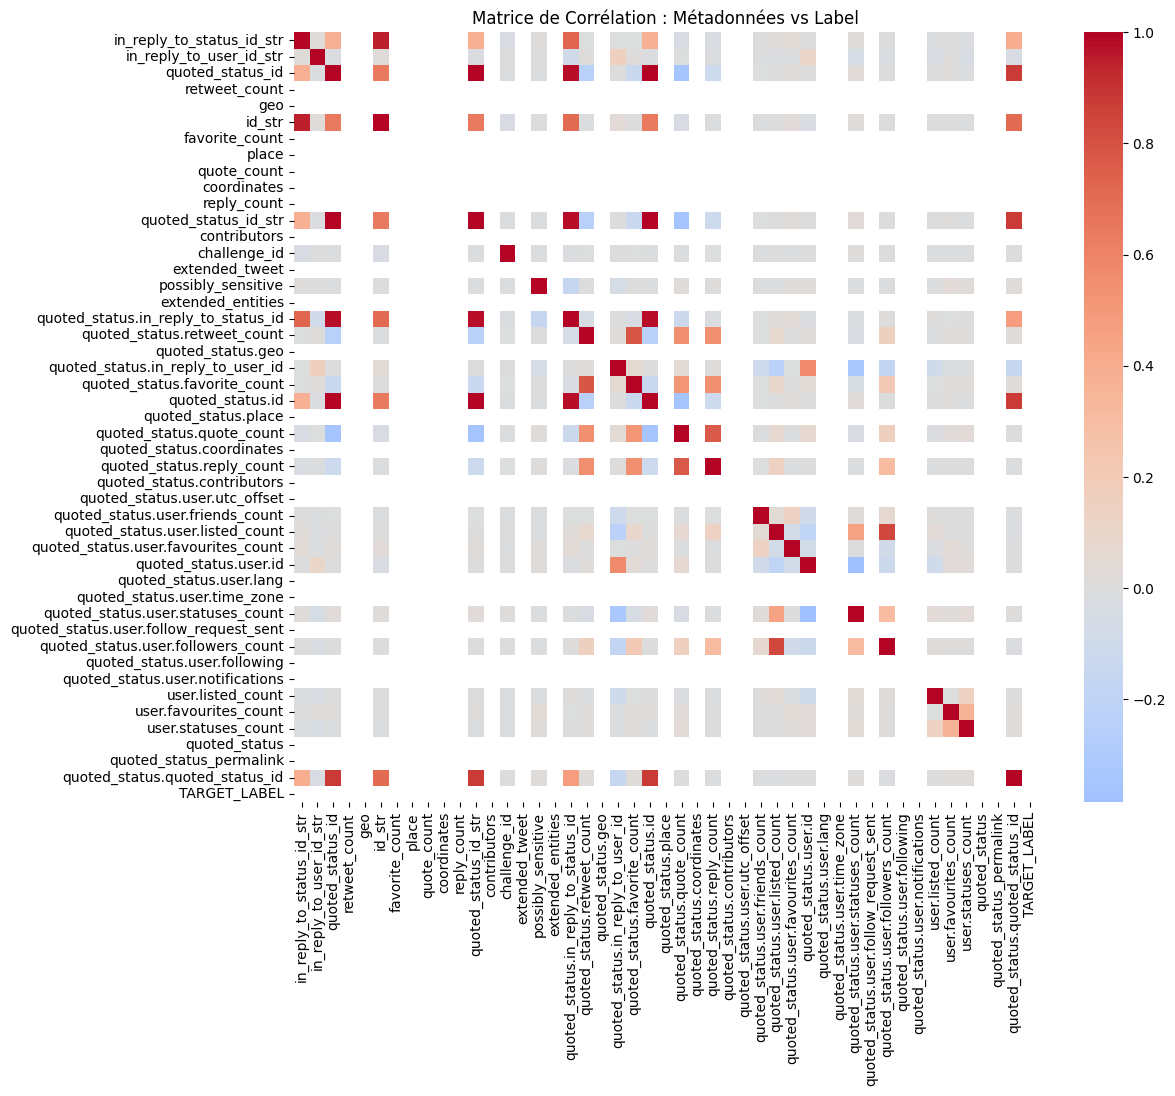

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Encodage de la target (y_train) pour l'analyse
# Adaptez le mapping selon vos labels exacts. Supposons ici 'influencer' et 'follower'
label_mapping = {'influencer': 1, 'follower': 0}
y_train_num = y_train.map(label_mapping)

# Si vos labels sont différents, vérifiez-les avec : print(y_train.unique())

# 2. Sélection des features numériques
# On sélectionne les types numériques
X_numeric = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32'])

# 3. Nettoyage des colonnes inutiles
# Les ID sont numériques mais n'ont pas de valeur prédictive (c'est du bruit)
cols_to_drop = ['id', 'user.id', 'in_reply_to_status_id', 'in_reply_to_user_id']
# On ne supprime que celles qui existent
X_numeric = X_numeric.drop(columns=[c for c in cols_to_drop if c in X_numeric.columns])

# 4. Création du DataFrame d'analyse (Features + Target)
analysis_df = pd.concat([X_numeric, y_train_num.rename('TARGET_LABEL')], axis=1)

# 5. Calcul et Affichage de la Matrice de Corrélation
plt.figure(figsize=(12, 10))
correlation_matrix = analysis_df.corr()

# On trie pour voir ce qui est le plus corrélé à la cible
print("Corrélation avec la cible :")
print(correlation_matrix['TARGET_LABEL'].sort_values(ascending=False))

# Affichage du graphique (Heatmap)
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Matrice de Corrélation : Métadonnées vs Label")
plt.show()

In [11]:
print(X_train.columns.tolist())

['in_reply_to_status_id_str', 'in_reply_to_status_id', 'created_at', 'in_reply_to_user_id_str', 'source', 'quoted_status_id', 'retweet_count', 'retweeted', 'geo', 'filter_level', 'in_reply_to_screen_name', 'is_quote_status', 'id_str', 'in_reply_to_user_id', 'favorite_count', 'text', 'place', 'lang', 'quote_count', 'favorited', 'coordinates', 'truncated', 'timestamp_ms', 'reply_count', 'quoted_status_id_str', 'contributors', 'challenge_id', 'extended_tweet', 'display_text_range', 'possibly_sensitive', 'extended_entities', 'withheld_in_countries', 'quoted_status.extended_tweet.entities.urls', 'quoted_status.extended_tweet.entities.hashtags', 'quoted_status.extended_tweet.entities.user_mentions', 'quoted_status.extended_tweet.entities.symbols', 'quoted_status.extended_tweet.full_text', 'quoted_status.extended_tweet.display_text_range', 'quoted_status.in_reply_to_status_id_str', 'quoted_status.in_reply_to_status_id', 'quoted_status.created_at', 'quoted_status.in_reply_to_user_id_str', 'quo

🔍 6 Features retenues :
['user.statuses_count', 'user.favourites_count', 'user.listed_count', 'possibly_sensitive', 'quoted_status.user.favourites_count', 'in_reply_to_status_id_str']

🚀 Entraînement sur 123931 tweets...


c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:47:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Accuracy sur le set de Validation : 0.8187

📊 Rapport détaillé :
              precision    recall  f1-score   support

           0       0.82      0.84      0.83     16535
           1       0.81      0.79      0.80     14448

    accuracy                           0.82     30983
   macro avg       0.82      0.82      0.82     30983
weighted avg       0.82      0.82      0.82     30983



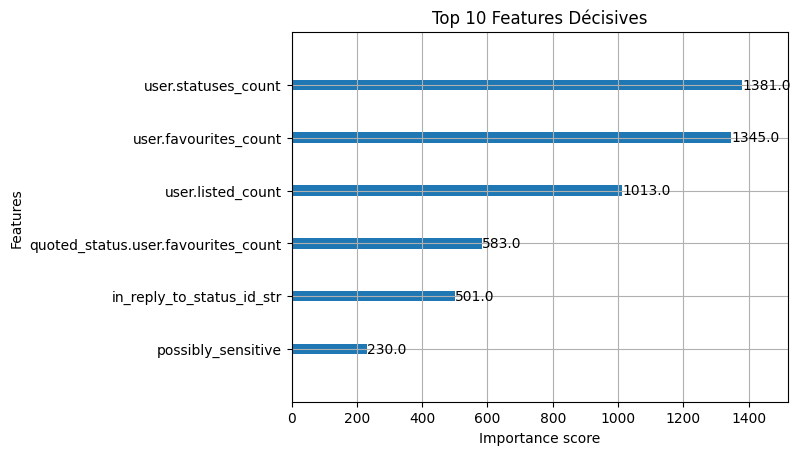

In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# =======================================================
# 1. PRÉPARATION (Plus besoin d'encoder y)
# =======================================================

# On s'assure que le label est bien un entier
y_final = y_train.astype(int)

# On ne garde que les colonnes numériques de X
X_numeric = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32'])

# On supprime les IDs qui ne servent à rien pour la prédiction
cols_to_drop = ['id', 'user.id', 'in_reply_to_status_id', 'in_reply_to_user_id']
X_numeric = X_numeric.drop(columns=[c for c in cols_to_drop if c in X_numeric.columns], errors='ignore')

# =======================================================
# 2. SÉLECTION DES FEATURES PAR CORRÉLATION
# =======================================================

# Calcul de la corrélation directe
df_analysis = X_numeric.copy()
df_analysis['target'] = y_final

corr_matrix = df_analysis.corr()

# On prend la valeur absolue pour voir l'intensité du lien
target_corr = corr_matrix['target'].abs().sort_values(ascending=False)

# On garde les features qui ont une corrélation > 0.05 (5%)
threshold = 0.05
selected_features = target_corr[target_corr > threshold].index.tolist()

# On retire la colonne 'target' de la liste
if 'target' in selected_features:
    selected_features.remove('target')

print(f"🔍 {len(selected_features)} Features retenues :")
print(selected_features)

# On filtre X avec ces features
X_final = X_numeric[selected_features]

# =======================================================
# 3. SPLIT ET ENTRAÎNEMENT
# =======================================================

# Split Train (80%) / Validation (20%)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_final, 
    y_final, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_final
)

print(f"\n🚀 Entraînement sur {len(X_train_split)} tweets...")

# Configuration du modèle XGBoost
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train_split, y_train_split)

# =======================================================
# 4. RÉSULTATS
# =======================================================

y_pred = model.predict(X_val_split)
acc = accuracy_score(y_val_split, y_pred)

print(f"\n✅ Accuracy sur le set de Validation : {acc:.4f}")
print("\n📊 Rapport détaillé :")
print(classification_report(y_val_split, y_pred))

# Affichage de l'importance des variables
xgb.plot_importance(model, max_num_features=10)
plt.title("Top 10 Features Décisives")
plt.show()

In [15]:
# =======================================================
# 4. PRÉDICTION SUR KAGGLE (TEST)
# =======================================================

print("\n🔮 Prédictions sur les données Kaggle...")

# ATTENTION : Il faut appliquer exactement la même sélection sur le jeu Kaggle
# 1. On s'assure que X_kaggle a les colonnes numériques
# 2. On ne garde QUE les colonnes 'selected_features'
# Si une colonne manque dans Kaggle (rare mais possible), on la remplit par 0
X_kaggle_optimized = X_kaggle[selected_features].copy()

# Prédiction
y_pred_kaggle = model.predict(X_kaggle_optimized)

# =======================================================
# 5. GÉNÉRATION DU FICHIER DE SOUMISSION
# =======================================================

# Utilisation de la notation demandée
output = pd.concat([X_kaggle['challenge_id'], pd.DataFrame(y_pred_kaggle)], axis=1, ignore_index=True)
output.columns = ['ID', "Prediction"]

# Sauvegarde
filename = 'submission_xgboost_metadata.csv'
output.to_csv(filename, index=False)

print(f"\n✓ Fichier généré avec succès : {filename}")
print(output.head())


🔮 Prédictions sur les données Kaggle...

✓ Fichier généré avec succès : submission_xgboost_metadata.csv
   ID  Prediction
0   0           1
1   2           1
2   4           0
3   8           0
4   9           0


En ajouant des features bien pensées (division, différences...)

In [20]:
import pandas as pd
import numpy as np
from datetime import datetime

def create_advanced_features(df_input):
    df = df_input.copy()
    
    # Définition des séries de fallback (robustesse contre les colonnes manquantes)
    default_int_series = pd.Series(0, index=df.index)
    default_bool_series = pd.Series(False, index=df.index)
    
    # --- Initialisation des colonnes numériques ---
    df['user.followers_count'] = df.get('user.followers_count', default_int_series).fillna(0)
    df['user.friends_count'] = df.get('user.friends_count', default_int_series).fillna(0)
    df['user.listed_count'] = df.get('user.listed_count', default_int_series).fillna(0)
    df['user.favourites_count'] = df.get('user.favourites_count', default_int_series).fillna(0)
    df['user.statuses_count'] = df.get('user.statuses_count', default_int_series).fillna(0)
    df['retweet_count'] = df.get('retweet_count', default_int_series).fillna(0)
    df['favorite_count'] = df.get('favorite_count', default_int_series).fillna(0)
    df['quote_count'] = df.get('quote_count', default_int_series).fillna(0) # Nouveau : Quote Count
    df['reply_count'] = df.get('reply_count', default_int_series).fillna(0) # Nouveau : Reply Count
    
    # --- A. GESTION DES DATES (Ancienneté du compte) ---
    df['user_created_at_dt'] = pd.to_datetime(df.get('user.created_at'), errors='coerce')
    ref_date = pd.to_datetime('now', utc=True)
    df['account_age_days'] = (ref_date - df['user_created_at_dt']).dt.days
    df['account_age_days'] = df['account_age_days'].fillna(0)
    
    # Extraction des indicateurs temporels avancés du tweet
    df['created_at_dt'] = pd.to_datetime(df.get('created_at'), errors='coerce')
    df['tweet_hour'] = df['created_at_dt'].dt.hour.fillna(-1)
    df['tweet_is_weekend'] = df['created_at_dt'].dt.dayofweek.isin([5, 6]).fillna(False).astype(int)

    # --- B. QUALITÉ DU PROFIL & STATUT (Booléens) ---
    df['is_default_profile'] = df.get('user.default_profile', default_bool_series).fillna(False).astype(int)
    df['is_default_image'] = df.get('user.default_profile_image', default_bool_series).fillna(False).astype(int)
    df['is_verified'] = df.get('user.verified', default_bool_series).fillna(False).astype(int)
    
    # Nouveau : Est-ce un compte protégé/privé ? (Signe d'un follower ou d'un utilisateur personnel)
    df['is_protected'] = df.get('user.protected', default_bool_series).fillna(False).astype(int)
    
    # Nouveau : Le profil a-t-il une URL renseignée ?
    df['has_url'] = df.get('user.url', pd.Series(False, index=df.index)).notna().astype(int)

    # --- C. CONTENU DU TWEET (Entities Counting) ---
    def count_entities(x):
        if isinstance(x, list) or (isinstance(x, pd.Series) and x.dtype == object): return len(x)
        return 0

    df['num_urls'] = df.get('entities.urls', default_int_series).apply(count_entities)
    df['num_hashtags'] = df.get('entities.hashtags', default_int_series).apply(count_entities)
    df['num_mentions'] = df.get('entities.user_mentions', default_int_series).apply(count_entities)
    df['has_media'] = df.get('extended_entities.media', default_bool_series).notna().astype(int)

    # --- D. RATIOS PUISSANTS & COMPORTEMENTAUX ---
    followers = df['user.followers_count']
    friends = df['user.friends_count']
    listed = df['user.listed_count']
    statuses = df['user.statuses_count']
    
    # 1. Ratio Followers / Friends (Ratio de notoriété)
    df['ratio_followers_friends'] = followers / (friends + 1)
    df['ratio_listed_followers'] = listed / (followers + 1)
    
    # 2. Taux de Réciprocité d'Amitié (Nouveau - Indique un équilibre/déséquilibre d'influence)
    df['reciprocity_score'] = (friends - followers) / (friends + followers + 1)

    # 3. Activité (Tweets par jour d'existence)
    df['tweets_per_day'] = statuses / (df['account_age_days'] + 1)
    
    # 4. Ratio Mention/Tweet (Nouveau - Taux d'interaction vs. diffusion)
    # Plus ce ratio est élevé, plus l'utilisateur interagit personnellement (follower).
    df['ratio_mention_status'] = df['num_mentions'] / (statuses + 1)
    
    # 5. Engagement (Taux d'engagement par Tweet)
    total_engagement = df['retweet_count'] + df['favorite_count'] + df['quote_count'] + df['reply_count']
    df['total_tweet_engagement'] = total_engagement / (followers + 1)

    # --- E. LONGUEUR DES TEXTES ---
    df['final_text'] = df.get('extended_tweet.full_text', df.get('text', pd.Series(''))).fillna('')
    df['final_text'] = df['final_text'].where(df['final_text'] != '', df.get('text', '')).fillna('')
    
    df['text_length'] = df['final_text'].astype(str).apply(len)
    df['bio_length'] = df.get('user.description', '').astype(str).apply(len)

    # --- F. SÉLECTION FINALE ---
    features_to_keep = [
        # Métriques User Brutes
        'user.followers_count', 'user.friends_count', 'user.listed_count', 
        'user.favourites_count', 'user.statuses_count',
        # Métriques Tweet Brutes
        'retweet_count', 'favorite_count', 'quote_count', 'reply_count',
        # Ratios & Comportementaux (NOUVEAU)
        'ratio_followers_friends', 'ratio_listed_followers', 'tweets_per_day', 'account_age_days',
        'reciprocity_score', 'ratio_mention_status', 'total_tweet_engagement',
        # Booléens & Qualité (MIS À JOUR)
        'is_verified', 'is_default_profile', 'is_default_image', 'is_geo_enabled',
        'is_protected', 'has_url',
        # Temporels (NOUVEAU)
        'tweet_hour', 'tweet_is_weekend',
        # Longueur du Contenu
        'text_length', 'bio_length', 
        # Compte des Entités
        'num_urls', 'num_hashtags', 'num_mentions', 'has_media'
    ]
    
    final_cols = [c for c in features_to_keep if c in df.columns]
    
    return df[final_cols].fillna(0)

# =======================================================
# 2. PIPELINE D'EXÉCUTION : APPLICATION ET TUNING
# =======================================================
print("🛠️ Construction des features avancées...")

# Application de la fonction robuste sur les deux DataFrames
X_train_advanced = create_advanced_features(X_train)
X_kaggle_advanced = create_advanced_features(X_kaggle)

# Préparation de la cible
y_train_clean = y_train.astype(int)

print(f"Features finales ({len(X_train_advanced.columns)}) : {list(X_train_advanced.columns)}")

# Vérification de l'alignement des colonnes (Critique pour la prédiction)
if not X_train_advanced.columns.equals(X_kaggle_advanced.columns):
    # Remplissage par 0 des colonnes manquantes dans l'autre set pour l'alignement
    common_cols = list(X_train_advanced.columns)
    X_kaggle_advanced = X_kaggle_advanced.reindex(columns=common_cols, fill_value=0)
    print("⚠️ Colonnes alignées entre Train et Kaggle.")

# =======================================================
# 3. ENTRAÎNEMENT ET PRÉDICTION
# =======================================================
print("\n🔄 Lancement du Random Search pour l'optimisation XGBoost...")

# Grille de paramètres
params = {
    'n_estimators': [150, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8, 10],           
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5]
}

xgb_model = xgb.XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss', 
    random_state=42,
    tree_method='hist' # Algorithme rapide pour les grands jeux de données
)

random_search = RandomizedSearchCV(
    xgb_model, 
    param_distributions=params, 
    n_iter=20, scoring='accuracy', cv=4, verbose=0, n_jobs=-1, random_state=42
)

random_search.fit(X_train_advanced, y_train_clean)

print(f"\n🏆 Meilleure Accuracy (Cross-Validation) : {random_search.best_score_:.4f}")
# print(f"Paramètres : {random_search.best_params_}") # Décommenter pour voir les params

# Prédiction sur le set Kaggle
best_model = random_search.best_estimator_
y_pred_kaggle = best_model.predict(X_kaggle_advanced)

# =======================================================
# 4. GÉNÉRATION DU FICHIER DE SOUMISSION
# =======================================================

output = pd.concat([X_kaggle['challenge_id'], pd.DataFrame(y_pred_kaggle)], axis=1, ignore_index=True)
output.columns = ['ID', "Prediction"]
output.to_csv('submission_xgboost_advanced_final.csv', index=False)

print("\n✓ Fichier 'submission_xgboost_advanced_final.csv' généré avec succès !")
print(output.head())

🛠️ Construction des features avancées...


C:\Users\hp1ma\AppData\Local\Temp\ipykernel_18928\3304155602.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['user_created_at_dt'] = pd.to_datetime(df.get('user.created_at'), errors='coerce')
C:\Users\hp1ma\AppData\Local\Temp\ipykernel_18928\3304155602.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['user_created_at_dt'] = pd.to_datetime(df.get('user.created_at'), errors='coerce')


Features finales (29) : ['user.followers_count', 'user.friends_count', 'user.listed_count', 'user.favourites_count', 'user.statuses_count', 'retweet_count', 'favorite_count', 'quote_count', 'reply_count', 'ratio_followers_friends', 'ratio_listed_followers', 'tweets_per_day', 'account_age_days', 'reciprocity_score', 'ratio_mention_status', 'total_tweet_engagement', 'is_verified', 'is_default_profile', 'is_default_image', 'is_protected', 'has_url', 'tweet_hour', 'tweet_is_weekend', 'text_length', 'bio_length', 'num_urls', 'num_hashtags', 'num_mentions', 'has_media']

🔄 Lancement du Random Search pour l'optimisation XGBoost...


c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:39:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🏆 Meilleure Accuracy (Cross-Validation) : 0.8789

✓ Fichier 'submission_xgboost_advanced_final.csv' généré avec succès !
   ID  Prediction
0   0           1
1   2           1
2   4           0
3   8           1
4   9           0


On va aussi prendre en compte a bio et analyser la tonalité des tweets

In [21]:
!pip install scikit-learn textblob

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 11.3 MB/s  0:00:00


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from textblob import TextBlob
import re

def create_nlp_features(df_train, df_test, y_train):
    """
    Crée des features NLP (TF-IDF des Bios et Sentiment des Tweets).

    Args:
        df_train (pd.DataFrame): DataFrame d'entraînement complet (X_train).
        df_test (pd.DataFrame): DataFrame de test (X_kaggle).
        y_train (pd.Series): Cible d'entraînement (y_train).

    Returns:
        tuple: (df_train_nlp, df_test_nlp) avec les nouvelles colonnes.
    """
    
    # ----------------------------------------
    # Préparation du texte
    # ----------------------------------------
    
    # Remplacer les NaN ou valeurs manquantes par une chaîne vide
    train_bio = df_train.get('user.description', pd.Series([''] * len(df_train))).fillna('').astype(str)
    test_bio = df_test.get('user.description', pd.Series([''] * len(df_test))).fillna('').astype(str)

    # Récupération du 'final_text' du tweet (le plus complet)
    # Note: On doit reproduire la logique de 'final_text' de la fonction d'ingénierie
    def get_final_text(df):
        text = df.get('text', pd.Series([''] * len(df))).fillna('')
        full_text = df.get('extended_tweet.full_text', text).fillna(text)
        return full_text.astype(str)
        
    train_text = get_final_text(df_train)
    test_text = get_final_text(df_test)

    # ----------------------------------------
    # A. TF-IDF sur les Bios (Meta-Feature)
    # ----------------------------------------
    print("  -> Calcul du TF-IDF sur les Bios et entraînement du Méta-Modèle...")
    
    # Nettoyage très basique du texte pour le TF-IDF
    def clean_text(text):
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Suppression des URLs
        text = re.sub(r'[^\w\s]', '', text) # Suppression de la ponctuation
        return text

    train_bio_clean = train_bio.apply(clean_text)
    test_bio_clean = test_bio.apply(clean_text)

    # 1. Création du Vecteur TF-IDF (Appris uniquement sur le training set)
    tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))
    X_train_tfidf = tfidf.fit_transform(train_bio_clean)
    X_test_tfidf = tfidf.transform(test_bio_clean)

    # 2. Entraînement du Méta-Modèle (Régression Logistique)
    log_reg = LogisticRegression(solver='liblinear', random_state=42)
    log_reg.fit(X_train_tfidf, y_train.astype(int))

    # 3. Extraction de la probabilité prédite (Meta-Feature)
    # Nous utilisons la probabilité pour la classe 1 (Influencer)
    train_bio_proba = log_reg.predict_proba(X_train_tfidf)[:, 1]
    test_bio_proba = log_reg.predict_proba(X_test_tfidf)[:, 1]

    # ----------------------------------------
    # B. Analyse du Sentiment (Polarity et Subjectivity)
    # ----------------------------------------
    print("  -> Extraction du Sentiment (Polarity/Subjectivity) des Tweets...")
    
    # La fonction TextBlob est utilisée pour obtenir les scores de sentiment
    # C'est une opération lente, il faut être patient
    def get_sentiment(text):
        try:
            analysis = TextBlob(text)
            return pd.Series({'polarity': analysis.sentiment.polarity, 'subjectivity': analysis.sentiment.subjectivity})
        except:
            return pd.Series({'polarity': 0.0, 'subjectivity': 0.0})

    train_sentiment = train_text.apply(get_sentiment)
    test_sentiment = test_text.apply(get_sentiment)

    # ----------------------------------------
    # 4. Fusion des Features NLP
    # ----------------------------------------
    
    # Création des DataFrames de features NLP
    df_train_nlp = pd.DataFrame({
        'meta_bio_proba': train_bio_proba,
        'tweet_polarity': train_sentiment['polarity'],
        'tweet_subjectivity': train_sentiment['subjectivity']
    })
    
    df_test_nlp = pd.DataFrame({
        'meta_bio_proba': test_bio_proba,
        'tweet_polarity': test_sentiment['polarity'],
        'tweet_subjectivity': test_sentiment['subjectivity']
    })

    return df_train_nlp, df_test_nlp

In [23]:
import pandas as pd
import numpy as np
from datetime import datetime

def create_advanced_features(df_input):
    df = df_input.copy()
    
    # Définition des séries de fallback (robustesse contre les colonnes manquantes)
    default_int_series = pd.Series(0, index=df.index)
    default_bool_series = pd.Series(False, index=df.index)
    
    # --- Initialisation des colonnes numériques ---
    df['user.followers_count'] = df.get('user.followers_count', default_int_series).fillna(0)
    df['user.friends_count'] = df.get('user.friends_count', default_int_series).fillna(0)
    df['user.listed_count'] = df.get('user.listed_count', default_int_series).fillna(0)
    df['user.favourites_count'] = df.get('user.favourites_count', default_int_series).fillna(0)
    df['user.statuses_count'] = df.get('user.statuses_count', default_int_series).fillna(0)
    df['retweet_count'] = df.get('retweet_count', default_int_series).fillna(0)
    df['favorite_count'] = df.get('favorite_count', default_int_series).fillna(0)
    df['quote_count'] = df.get('quote_count', default_int_series).fillna(0) # Nouveau : Quote Count
    df['reply_count'] = df.get('reply_count', default_int_series).fillna(0) # Nouveau : Reply Count
    
    # --- A. GESTION DES DATES (Ancienneté du compte) ---
    df['user_created_at_dt'] = pd.to_datetime(df.get('user.created_at'), errors='coerce')
    ref_date = pd.to_datetime('now', utc=True)
    df['account_age_days'] = (ref_date - df['user_created_at_dt']).dt.days
    df['account_age_days'] = df['account_age_days'].fillna(0)
    
    # Extraction des indicateurs temporels avancés du tweet
    df['created_at_dt'] = pd.to_datetime(df.get('created_at'), errors='coerce')
    df['tweet_hour'] = df['created_at_dt'].dt.hour.fillna(-1)
    df['tweet_is_weekend'] = df['created_at_dt'].dt.dayofweek.isin([5, 6]).fillna(False).astype(int)

    # --- B. QUALITÉ DU PROFIL & STATUT (Booléens) ---
    df['is_default_profile'] = df.get('user.default_profile', default_bool_series).fillna(False).astype(int)
    df['is_default_image'] = df.get('user.default_profile_image', default_bool_series).fillna(False).astype(int)
    df['is_verified'] = df.get('user.verified', default_bool_series).fillna(False).astype(int)
    
    # Nouveau : Est-ce un compte protégé/privé ? (Signe d'un follower ou d'un utilisateur personnel)
    df['is_protected'] = df.get('user.protected', default_bool_series).fillna(False).astype(int)
    
    # Nouveau : Le profil a-t-il une URL renseignée ?
    df['has_url'] = df.get('user.url', pd.Series(False, index=df.index)).notna().astype(int)

    # --- C. CONTENU DU TWEET (Entities Counting) ---
    def count_entities(x):
        if isinstance(x, list) or (isinstance(x, pd.Series) and x.dtype == object): return len(x)
        return 0

    df['num_urls'] = df.get('entities.urls', default_int_series).apply(count_entities)
    df['num_hashtags'] = df.get('entities.hashtags', default_int_series).apply(count_entities)
    df['num_mentions'] = df.get('entities.user_mentions', default_int_series).apply(count_entities)
    df['has_media'] = df.get('extended_entities.media', default_bool_series).notna().astype(int)

    # --- D. RATIOS PUISSANTS & COMPORTEMENTAUX ---
    followers = df['user.followers_count']
    friends = df['user.friends_count']
    listed = df['user.listed_count']
    statuses = df['user.statuses_count']
    
    # 1. Ratio Followers / Friends (Ratio de notoriété)
    df['ratio_followers_friends'] = followers / (friends + 1)
    df['ratio_listed_followers'] = listed / (followers + 1)
    
    # 2. Taux de Réciprocité d'Amitié (Nouveau - Indique un équilibre/déséquilibre d'influence)
    df['reciprocity_score'] = (friends - followers) / (friends + followers + 1)

    # 3. Activité (Tweets par jour d'existence)
    df['tweets_per_day'] = statuses / (df['account_age_days'] + 1)
    
    # 4. Ratio Mention/Tweet (Nouveau - Taux d'interaction vs. diffusion)
    # Plus ce ratio est élevé, plus l'utilisateur interagit personnellement (follower).
    df['ratio_mention_status'] = df['num_mentions'] / (statuses + 1)
    
    # 5. Engagement (Taux d'engagement par Tweet)
    total_engagement = df['retweet_count'] + df['favorite_count'] + df['quote_count'] + df['reply_count']
    df['total_tweet_engagement'] = total_engagement / (followers + 1)

    # --- E. LONGUEUR DES TEXTES ---
    df['final_text'] = df.get('extended_tweet.full_text', df.get('text', pd.Series(''))).fillna('')
    df['final_text'] = df['final_text'].where(df['final_text'] != '', df.get('text', '')).fillna('')
    
    df['text_length'] = df['final_text'].astype(str).apply(len)
    df['bio_length'] = df.get('user.description', '').astype(str).apply(len)

    # --- F. SÉLECTION FINALE ---
    features_to_keep = [
        # Métriques User Brutes
        'user.followers_count', 'user.friends_count', 'user.listed_count', 
        'user.favourites_count', 'user.statuses_count',
        # Métriques Tweet Brutes
        'retweet_count', 'favorite_count', 'quote_count', 'reply_count',
        # Ratios & Comportementaux (NOUVEAU)
        'ratio_followers_friends', 'ratio_listed_followers', 'tweets_per_day', 'account_age_days',
        'reciprocity_score', 'ratio_mention_status', 'total_tweet_engagement',
        # Booléens & Qualité (MIS À JOUR)
        'is_verified', 'is_default_profile', 'is_default_image', 'is_geo_enabled',
        'is_protected', 'has_url',
        # Temporels (NOUVEAU)
        'tweet_hour', 'tweet_is_weekend',
        # Longueur du Contenu
        'text_length', 'bio_length', 
        # Compte des Entités
        'num_urls', 'num_hashtags', 'num_mentions', 'has_media'
    ]
    
    final_cols = [c for c in features_to_keep if c in df.columns]
    
    return df[final_cols].fillna(0)

# =======================================================
# 2. PIPELINE D'EXÉCUTION : APPLICATION ET TUNING
# =======================================================
print("🛠️ Construction des features avancées (Métadonnées)...")

# Application de la fonction robuste (Métadonnées)
X_train_advanced = create_advanced_features(X_train)
X_kaggle_advanced = create_advanced_features(X_kaggle)

# Préparation de la cible
y_train_clean = y_train.astype(int)

# --- NOUVELLE ÉTAPE : CRÉATION DES FEATURES NLP ---
X_train_nlp, X_kaggle_nlp = create_nlp_features(X_train, X_kaggle, y_train_clean)

# --- FUSION DES FEATURES ---
X_train_advanced = pd.concat([X_train_advanced, X_train_nlp], axis=1)
X_kaggle_advanced = pd.concat([X_kaggle_advanced, X_kaggle_nlp], axis=1)

print(f"\nFeatures finales combinées ({len(X_train_advanced.columns)}):")
print(list(X_train_advanced.columns))

# =======================================================
# 3. ENTRAÎNEMENT ET PRÉDICTION
# =======================================================
print("\n🔄 Lancement du Random Search pour l'optimisation XGBoost...")

# Grille de paramètres
params = {
    'n_estimators': [150, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8, 10],           
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5]
}

xgb_model = xgb.XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss', 
    random_state=42,
    tree_method='hist' # Algorithme rapide pour les grands jeux de données
)

random_search = RandomizedSearchCV(
    xgb_model, 
    param_distributions=params, 
    n_iter=20, scoring='accuracy', cv=4, verbose=0, n_jobs=-1, random_state=42
)

random_search.fit(X_train_advanced, y_train_clean)

print(f"\n🏆 Meilleure Accuracy (Cross-Validation) : {random_search.best_score_:.4f}")
# print(f"Paramètres : {random_search.best_params_}") # Décommenter pour voir les params

# Prédiction sur le set Kaggle
best_model = random_search.best_estimator_
y_pred_kaggle = best_model.predict(X_kaggle_advanced)

# =======================================================
# 4. GÉNÉRATION DU FICHIER DE SOUMISSION
# =======================================================

output = pd.concat([X_kaggle['challenge_id'], pd.DataFrame(y_pred_kaggle)], axis=1, ignore_index=True)
output.columns = ['ID', "Prediction"]
output.to_csv('submission_xgboost_advanced_final.csv', index=False)

print("\n✓ Fichier 'submission_xgboost_advanced_final.csv' généré avec succès !")
print(output.head())

🛠️ Construction des features avancées (Métadonnées)...


C:\Users\hp1ma\AppData\Local\Temp\ipykernel_18928\3788918136.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['user_created_at_dt'] = pd.to_datetime(df.get('user.created_at'), errors='coerce')
C:\Users\hp1ma\AppData\Local\Temp\ipykernel_18928\3788918136.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['user_created_at_dt'] = pd.to_datetime(df.get('user.created_at'), errors='coerce')


  -> Calcul du TF-IDF sur les Bios et entraînement du Méta-Modèle...
  -> Extraction du Sentiment (Polarity/Subjectivity) des Tweets...

Features finales combinées (32):
['user.followers_count', 'user.friends_count', 'user.listed_count', 'user.favourites_count', 'user.statuses_count', 'retweet_count', 'favorite_count', 'quote_count', 'reply_count', 'ratio_followers_friends', 'ratio_listed_followers', 'tweets_per_day', 'account_age_days', 'reciprocity_score', 'ratio_mention_status', 'total_tweet_engagement', 'is_verified', 'is_default_profile', 'is_default_image', 'is_protected', 'has_url', 'tweet_hour', 'tweet_is_weekend', 'text_length', 'bio_length', 'num_urls', 'num_hashtags', 'num_mentions', 'has_media', 'meta_bio_proba', 'tweet_polarity', 'tweet_subjectivity']

🔄 Lancement du Random Search pour l'optimisation XGBoost...


c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:58:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🏆 Meilleure Accuracy (Cross-Validation) : 0.8876

✓ Fichier 'submission_xgboost_advanced_final.csv' généré avec succès !
   ID  Prediction
0   0           1
1   2           1
2   4           0
3   8           1
4   9           0


On tente de stacker différents classifieurs (random forest, xgboost, logregre), en se disant que les faiblesses de l'un peuvent etre conpensés par les autres : 

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 3. Fusion des DataFrames
X_train_stack = pd.concat([X_train_advanced, X_train_nlp], axis=1).fillna(0)
X_kaggle_stack = pd.concat([X_kaggle_advanced, X_kaggle_nlp], axis=1).fillna(0)

# Alignement des colonnes (critique pour le stacking)
common_cols = list(X_train_stack.columns)
X_kaggle_stack = X_kaggle_stack.reindex(columns=common_cols, fill_value=0)

# Création d'un ensemble de features normalisées (pour la LogReg et les autres modèles sensibles à l'échelle)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_stack)
X_kaggle_scaled = scaler.transform(X_kaggle_stack)

# =======================================================
# 2. INITIALISATION DES MODÈLES ET DU STACKING
# =======================================================
print("--- 1. Optimisation des Modèles de Base ---")

# 1. TUNING XGBOOST
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, tree_method='hist')
xgb_params = {
    'n_estimators': [100, 300, 500], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [4, 6, 8, 10], 'subsample': [0.7, 0.8, 0.9], 'gamma': [0, 0.1, 0.5], 'colsample_bytree': [0.6, 0.8, 1.0]
}
xgb_search = RandomizedSearchCV(xgb_model, xgb_params, n_iter=20, scoring='accuracy', cv=3, verbose=0, n_jobs=-1, random_state=42)
xgb_search.fit(X_train_stack, y_train_clean)
best_xgb = xgb_search.best_estimator_
print(f"Meilleur XGBoost trouvé (Acc. {xgb_search.best_score_:.4f})")

# 2. TUNING RANDOM FOREST
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_params = {
    'n_estimators': [300, 500, 700],
    'max_depth': [8, 12, 16, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [3, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}
rf_search = RandomizedSearchCV(rf_model, rf_params, n_iter=20, scoring='accuracy', cv=3, verbose=0, n_jobs=-1, random_state=42)
rf_search.fit(X_train_stack, y_train_clean)
best_rf = rf_search.best_estimator_
print(f"Meilleur Random Forest trouvé (Acc. {rf_search.best_score_:.4f})")

# 3. TUNING RÉGRESSION LOGISTIQUE (sur données scaled)
# Nous tunons le paramètre de régularisation C
logreg_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
logreg_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}
logreg_search = RandomizedSearchCV(logreg_model, logreg_params, n_iter=8, scoring='accuracy', cv=3, verbose=0, n_jobs=-1, random_state=42)
logreg_search.fit(X_train_scaled, y_train_clean)
best_logreg = logreg_search.best_estimator_
print(f"Meilleure LogReg trouvée (Acc. {logreg_search.best_score_:.4f})")

# Mise à jour de la liste des modèles de base avec les versions optimisées
base_models = [
    ('XGBoost', best_xgb),
    ('RandomForest', best_rf),
    ('LogReg', best_logreg)
]

# --- 2. Boucle K-Fold Stratifié pour la génération OOF ---

N_TRAIN = X_train_stack.shape[0]
N_TEST = X_kaggle_stack.shape[0]
N_MODELS = len(base_models)
N_SPLITS = 5 

X_meta_train = np.zeros((N_TRAIN, N_MODELS))
X_meta_test = np.zeros((N_TEST, N_MODELS))

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

print(f"\n--- 2. Génération des Méta-Features OOF ({N_SPLITS} plis) ---")

for i, (name, model) in enumerate(base_models):
    print(f"  -> Génération OOF pour le modèle optimisé: {name}")
    
    test_preds_fold = np.zeros((N_TEST, N_SPLITS))
    
    # 1. Sélectionner le bon jeu de données (Pandas DataFrame ou NumPy Scaled Array)
    # L'entraînement se fait désormais sur les modèles OPTIMISÉS.
    if name == 'LogReg':
        X_train_data = X_train_scaled
        X_test_data = X_kaggle_scaled
        is_pandas_df = False
    else:
        X_train_data = X_train_stack
        X_test_data = X_kaggle_stack
        is_pandas_df = True

    for fold, (train_index, val_index) in enumerate(skf.split(X_train_stack, y_train_clean)):
        
        # Séparation des données
        if is_pandas_df:
            X_train_fold = X_train_data.iloc[train_index]
            X_val_fold = X_train_data.iloc[val_index]
        else:
            X_train_fold = X_train_data[train_index]
            X_val_fold = X_train_data[val_index]
        
        y_train_fold, y_val_fold = y_train_clean.iloc[train_index], y_train_clean.iloc[val_index]

        # Entraînement sur les plis
        model.fit(X_train_fold, y_train_fold)

        # Prédiction OOF
        X_meta_train[val_index, i] = model.predict_proba(X_val_fold)[:, 1]

        # Prédiction de Test (Moyenne par la suite)
        if is_pandas_df:
            test_preds_fold[:, fold] = model.predict_proba(X_test_data.values)[:, 1]
        else:
            test_preds_fold[:, fold] = model.predict_proba(X_test_data)[:, 1]
        
    X_meta_test[:, i] = test_preds_fold.mean(axis=1)

print("\nMatrice Méta-Features OOF créée.")

# --- 3. Entraînement du Méta-Modèle et Prédiction ---
meta_model = LogisticRegression(solver='liblinear', random_state=42)
meta_model.fit(X_meta_train, y_train_clean)
# ... (le reste du code de prédiction et de génération de fichier reste identique)

# =======================================================
# 4. ENTRAÎNEMENT DU MÉTA-MODÈLE ET PRÉDICTION FINALE
# =======================================================

# Le Méta-Modèle (Meta-Learner): Une Régression Logistique simple
meta_model = LogisticRegression(solver='liblinear', random_state=42)

# Entraînement sur les probabilités des modèles de base
meta_model.fit(X_meta_train, y_train_clean)

# Prédiction finale sur le jeu de test Kaggle
y_pred_proba_meta = meta_model.predict_proba(X_meta_test)[:, 1]
y_pred_kaggle_stack = (y_pred_proba_meta > 0.5).astype(int)

# Score OOF du Méta-Modèle (utilisez ceci comme validation croisée du stacking)
oof_proba = meta_model.predict_proba(X_meta_train)[:, 1]
oof_acc = accuracy_score(y_train_clean, (oof_proba > 0.5).astype(int))

print(f"🏆 Accuracy OOF du Stacking (Méta-Modèle) : {oof_acc:.4f}")

# =======================================================
# 5. GÉNÉRATION DU FICHIER DE SOUMISSION
# =======================================================

output = pd.concat([X_kaggle['challenge_id'], pd.DataFrame(y_pred_kaggle_stack)], axis=1, ignore_index=True)
output.columns = ['ID', "Prediction"]
output.to_csv('submission_stacking_final.csv', index=False)

print("\n✓ Fichier 'submission_stacking_final.csv' généré avec le Stacking.")

--- 1. Optimisation des Modèles de Base ---


c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:36:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Meilleur XGBoost trouvé (Acc. 0.8827)
Meilleur Random Forest trouvé (Acc. 0.8602)
Meilleure LogReg trouvée (Acc. 0.8014)

--- 2. Génération des Méta-Features OOF (5 plis) ---
  -> Génération OOF pour le modèle optimisé: XGBoost


c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_

  -> Génération OOF pour le modèle optimisé: RandomForest


c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


  -> Génération OOF pour le modèle optimisé: LogReg

Matrice Méta-Features OOF créée.
🏆 Accuracy OOF du Stacking (Méta-Modèle) : 0.9332

✓ Fichier 'submission_stacking_final.csv' généré avec le Stacking.


In [30]:
print("Paramètres XGBoost optimaux :")
print(xgb_search.best_params_)
print("Paramètres Random Forest optimaux :")
print(rf_search.best_params_)
print("Paramètres Régression Logistique optimaux :")
print(logreg_search.best_params_)

Paramètres XGBoost optimaux :
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}
Paramètres Random Forest optimaux :
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}
Paramètres Régression Logistique optimaux :
{'solver': 'liblinear', 'penalty': 'l2', 'class_weight': None, 'C': 1}


Le stacking de boost pas les perf en pratique, il faudrait peut-etre tenté avec des SVM.... Ci-dessous, on ne fait plus de stacking mais on ajoute des features sur les tweets et sur la bio: 

In [32]:
import pandas as pd
import numpy as np
from datetime import datetime

def create_advanced_features(df_input):
    df = df_input.copy()
    
    # Définition des séries de fallback (robustesse contre les colonnes manquantes)
    default_int_series = pd.Series(0, index=df.index)
    default_bool_series = pd.Series(False, index=df.index)
    
    # --- Initialisation des colonnes numériques ---
    df['user.followers_count'] = df.get('user.followers_count', default_int_series).fillna(0)
    df['user.friends_count'] = df.get('user.friends_count', default_int_series).fillna(0)
    df['user.listed_count'] = df.get('user.listed_count', default_int_series).fillna(0)
    df['user.favourites_count'] = df.get('user.favourites_count', default_int_series).fillna(0)
    df['user.statuses_count'] = df.get('user.statuses_count', default_int_series).fillna(0)
    df['retweet_count'] = df.get('retweet_count', default_int_series).fillna(0)
    df['favorite_count'] = df.get('favorite_count', default_int_series).fillna(0)
    df['quote_count'] = df.get('quote_count', default_int_series).fillna(0) # Nouveau : Quote Count
    df['reply_count'] = df.get('reply_count', default_int_series).fillna(0) # Nouveau : Reply Count
    
    # --- A. GESTION DES DATES (Ancienneté du compte) ---
    df['user_created_at_dt'] = pd.to_datetime(df.get('user.created_at'), errors='coerce')
    ref_date = pd.to_datetime('now', utc=True)
    df['account_age_days'] = (ref_date - df['user_created_at_dt']).dt.days
    df['account_age_days'] = df['account_age_days'].fillna(0)
    
    # Extraction des indicateurs temporels avancés du tweet
    df['created_at_dt'] = pd.to_datetime(df.get('created_at'), errors='coerce')
    df['tweet_hour'] = df['created_at_dt'].dt.hour.fillna(-1)
    df['tweet_is_weekend'] = df['created_at_dt'].dt.dayofweek.isin([5, 6]).fillna(False).astype(int)

    # --- B. QUALITÉ DU PROFIL & STATUT (Booléens) ---
    df['is_default_profile'] = df.get('user.default_profile', default_bool_series).fillna(False).astype(int)
    df['is_default_image'] = df.get('user.default_profile_image', default_bool_series).fillna(False).astype(int)
    df['is_verified'] = df.get('user.verified', default_bool_series).fillna(False).astype(int)
    
    # Nouveau : Est-ce un compte protégé/privé ? (Signe d'un follower ou d'un utilisateur personnel)
    df['is_protected'] = df.get('user.protected', default_bool_series).fillna(False).astype(int)
    
    # Nouveau : Le profil a-t-il une URL renseignée ?
    df['has_url'] = df.get('user.url', pd.Series(False, index=df.index)).notna().astype(int)

    # --- C. CONTENU DU TWEET (Entities Counting) ---
    def count_entities(x):
        if isinstance(x, list) or (isinstance(x, pd.Series) and x.dtype == object): return len(x)
        return 0

    df['num_urls'] = df.get('entities.urls', default_int_series).apply(count_entities)
    df['num_hashtags'] = df.get('entities.hashtags', default_int_series).apply(count_entities)
    df['num_mentions'] = df.get('entities.user_mentions', default_int_series).apply(count_entities)
    df['has_media'] = df.get('extended_entities.media', default_bool_series).notna().astype(int)

    # --- D. RATIOS PUISSANTS & COMPORTEMENTAUX ---
    followers = df['user.followers_count']
    friends = df['user.friends_count']
    listed = df['user.listed_count']
    statuses = df['user.statuses_count']
    
    # 1. Ratio Followers / Friends (Ratio de notoriété)
    df['ratio_followers_friends'] = followers / (friends + 1)
    df['ratio_listed_followers'] = listed / (followers + 1)
    
    # 2. Taux de Réciprocité d'Amitié (Nouveau - Indique un équilibre/déséquilibre d'influence)
    df['reciprocity_score'] = (friends - followers) / (friends + followers + 1)

    # 3. Activité (Tweets par jour d'existence)
    df['tweets_per_day'] = statuses / (df['account_age_days'] + 1)
    
    # 4. Ratio Mention/Tweet (Nouveau - Taux d'interaction vs. diffusion)
    # Plus ce ratio est élevé, plus l'utilisateur interagit personnellement (follower).
    df['ratio_mention_status'] = df['num_mentions'] / (statuses + 1)
    
    # 5. Engagement (Taux d'engagement par Tweet)
    total_engagement = df['retweet_count'] + df['favorite_count'] + df['quote_count'] + df['reply_count']
    df['total_tweet_engagement'] = total_engagement / (followers + 1)

    # --- E. LONGUEUR DES TEXTES ---
    df['final_text'] = df.get('extended_tweet.full_text', df.get('text', pd.Series(''))).fillna('')
    df['final_text'] = df['final_text'].where(df['final_text'] != '', df.get('text', '')).fillna('')
    
    df['text_length'] = df['final_text'].astype(str).apply(len)
    df['bio_length'] = df.get('user.description', '').astype(str).apply(len)

    # --- F. SÉLECTION FINALE ---
    features_to_keep = [
        # Métriques User Brutes
        'user.followers_count', 'user.friends_count', 'user.listed_count', 
        'user.favourites_count', 'user.statuses_count',
        # Métriques Tweet Brutes
        'retweet_count', 'favorite_count', 'quote_count', 'reply_count',
        # Ratios & Comportementaux (NOUVEAU)
        'ratio_followers_friends', 'ratio_listed_followers', 'tweets_per_day', 'account_age_days',
        'reciprocity_score', 'ratio_mention_status', 'total_tweet_engagement',
        # Booléens & Qualité (MIS À JOUR)
        'is_verified', 'is_default_profile', 'is_default_image', 'is_geo_enabled',
        'is_protected', 'has_url',
        # Temporels (NOUVEAU)
        'tweet_hour', 'tweet_is_weekend',
        # Longueur du Contenu
        'text_length', 'bio_length', 
        # Compte des Entités
        'num_urls', 'num_hashtags', 'num_mentions', 'has_media'
    ]
    
    final_cols = [c for c in features_to_keep if c in df.columns]
    
    return df[final_cols].fillna(0)



In [ ]:
# =======================================================
# 2. PIPELINE D'EXÉCUTION : APPLICATION ET TUNING
# =======================================================
print("🛠️ Construction des features avancées (Métadonnées)...")

# Application de la fonction robuste (Métadonnées)
X_train_advanced = create_advanced_features(X_train)
X_kaggle_advanced = create_advanced_features(X_kaggle)

# Préparation de la cible
y_train_clean = y_train.astype(int)

# --- NOUVELLE ÉTAPE : CRÉATION DES FEATURES NLP ---
X_train_nlp, X_kaggle_nlp = create_nlp_features(X_train, X_kaggle, y_train_clean)

# --- FUSION DES FEATURES ---
X_train_advanced = pd.concat([X_train_advanced, X_train_nlp], axis=1)
X_kaggle_advanced = pd.concat([X_kaggle_advanced, X_kaggle_nlp], axis=1)

print(f"\nFeatures finales combinées ({len(X_train_advanced.columns)}):")
print(list(X_train_advanced.columns))



🛠️ Construction des features avancées (Métadonnées)...


C:\Users\hp1ma\AppData\Local\Temp\ipykernel_18928\1395220860.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['user_created_at_dt'] = pd.to_datetime(df.get('user.created_at'), errors='coerce')


KeyboardInterrupt: 

In [41]:
# =======================================================
# 3. ENTRAÎNEMENT ET PRÉDICTION
# =======================================================
print("\n🔄 Lancement du Random Search pour l'optimisation XGBoost...")

# Grille de paramètres
params = {
    'n_estimators': [300],
    'learning_rate': [0.1],
    'max_depth': [25, 30, 50],           
    'subsample': [0.9],
    'colsample_bytree': [1.0],
    'gamma': [0.5]
}

xgb_model = xgb.XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss', 
    random_state=42,
    tree_method='hist' # Algorithme rapide pour les grands jeux de données
)

random_search = RandomizedSearchCV(
    xgb_model, 
    param_distributions=params, 
    n_iter=5, scoring='accuracy', cv=4, verbose=0, n_jobs=-1, random_state=42
)

random_search.fit(X_train_advanced, y_train_clean)

print(f"\n🏆 Meilleure Accuracy (Cross-Validation) : {random_search.best_score_:.4f}")
# print(f"Paramètres : {random_search.best_params_}") # Décommenter pour voir les params

# Prédiction sur le set Kaggle
best_model = random_search.best_estimator_
y_pred_kaggle = best_model.predict(X_kaggle_advanced)

# =======================================================
# 4. GÉNÉRATION DU FICHIER DE SOUMISSION
# =======================================================

output = pd.concat([X_kaggle['challenge_id'], pd.DataFrame(y_pred_kaggle)], axis=1, ignore_index=True)
output.columns = ['ID', "Prediction"]
output.to_csv('submission_xgboost_advanced_final.csv', index=False)

print("\n✓ Fichier 'submission_xgboost_advanced_final.csv' généré avec succès !")
print(output.head())


🔄 Lancement du Random Search pour l'optimisation XGBoost...


c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\hp1ma\anaconda3\envs\inf554\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:35:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🏆 Meilleure Accuracy (Cross-Validation) : 0.8985

✓ Fichier 'submission_xgboost_advanced_final.csv' généré avec succès !
   ID  Prediction
0   0           1
1   2           1
2   4           0
3   8           1
4   9           0


In [42]:
print("Paramètres XGBoost optimaux :")
print(random_search.best_params_)


Paramètres XGBoost optimaux :
{'subsample': 0.9, 'n_estimators': 300, 'max_depth': 50, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}
